This notebook is part of the `kikuchipy` documentation https://kikuchipy.org.
Links to the documentation won't work from the notebook.

# Non-local pattern averaging

Non-local pattern averaging (NLPAR) reduces the noise in EBSD patterns by replacing every pattern with a weighted mean of the patterns in a search window around it (<cite data-cite="brewick2019nlpar">Brewick et al. (2019)</cite>).
The weight of a neighbour decays with its distance to the pattern, measured in units of the estimated noise level of the two patterns.
Neighbours from the same grain differ mostly by noise and get a large weight, while neighbours from another grain differ by their Kikuchi bands and get (almost) no weight.
Noise is therefore reduced within grains while grain boundaries stay sharp.
This is the difference to the fixed averaging window of [average_neighbour_patterns()](../reference/generated/kikuchipy.signals.EBSD.average_neighbour_patterns.rst), shown in the [pattern processing tutorial](pattern_processing.ipynb#Average-neighbour-patterns).

kikuchipy provides three methods of the [EBSD](../reference/generated/kikuchipy.signals.EBSD.rst) signal for NLPAR:

* [get_nlpar_sigma()](../reference/generated/kikuchipy.signals.EBSD.get_nlpar_sigma.rst) returns the estimated noise level of every pattern,
* [get_nlpar_lambda()](../reference/generated/kikuchipy.signals.EBSD.get_nlpar_lambda.rst) returns an optimised weight decay lambda for a target weight, and
* [average_non_local_neighbour_patterns()](../reference/generated/kikuchipy.signals.EBSD.average_non_local_neighbour_patterns.rst) averages the patterns.

The [hybrid indexing tutorial](hybrid_indexing.ipynb) closes by pointing to NLPAR in [PyEBSDIndex](https://pyebsdindex.readthedocs.io).
The methods used here run without PyEBSDIndex, but their kernels are derived from PyEBSDIndex's NLPAR implementation (public domain).
The US Naval Research Laboratory (David Rowenhorst) is gratefully acknowledged as the original source of the NLPAR implementation.

In this tutorial, we explain the formulas, show on a synthetic map of two grains why NLPAR keeps a grain boundary sharp, and apply NLPAR to a nickel dataset, measuring its effect on feature maps and on Hough indexing.
We then average a very noisy nickel dataset and score its Hough indexing against a low-noise map of the same region.
We close with advice on the parameters and on large datasets, and list how this implementation differs from others.

In [1]:
# Exchange inline for notebook or qt5 (from pyqt) for interactive plotting
%matplotlib inline

import dask
import hyperspy.api as hs
import matplotlib.pyplot as plt
import numpy as np

import kikuchipy as kp
from orix.crystal_map import PhaseList
from orix.quaternion import Orientation

plt.rcParams.update({"figure.facecolor": "w", "font.size": 12})

# Silence progressbars
hs.preferences.General.show_progressbar = False

The averaging runs in parallel over chunks of patterns with Dask's threaded scheduler.
We limit it to eight worker threads; leave this out to use all cores.
The results do not depend on the number of workers.

In [2]:
_ = dask.config.set(num_workers=8)

## The formulas

Let $p_{ik}$ be the intensity of pixel $k$ in pattern $i$, and let $n_{ij}$ be the number of pixels compared between patterns $i$ and $j$.
These are all pixels not excluded by a `signal_mask`, and, with `saturation_protect=True` (the default), only pixels where both values are below a saturation threshold near the maximum of the map.
With the squared distance $D_{ij} = \sum_k (p_{ik} - p_{jk})^2$, the noise level $\sigma_i$ of pattern $i$ is estimated from its nearest neighbours $j$ in the $3 \times 3$ neighbourhood as

$$
\sigma_i^2 = \min_j \frac{D_{ij}}{2 n_{ij}}.
$$

If patterns $i$ and $j$ are the same pattern plus independent noise, $D_{ij}$ has the expectation $n_{ij} (\sigma_i^2 + \sigma_j^2)$, and the minimum over the neighbours picks the most similar one.
The distance is then normalised by its expected spread

$$
d_{ij} = \frac{D_{ij} - n_{ij} (\sigma_i^2 + \sigma_j^2)}{(\sigma_i^2 + \sigma_j^2) \sqrt{2 n_{ij}}},
$$

so that $d_{ij}$ is of order one for two patterns that differ by noise only, and grows with the number of pixels for patterns that differ by their Kikuchi bands.
The weight of neighbour $j$ and the averaged pattern are

$$
w_{ij} = \exp\left(-\frac{\max(d_{ij} - d_\mathrm{thresh}, 0)}{\lambda^2}\right), \quad w_{ii} = 1, \qquad
p_i' = \frac{\sum_j w_{ij} p_j}{\sum_j w_{ij}},
$$

where the sums run over the search window around pattern $i$.
The parameters of `average_non_local_neighbour_patterns()` enter as follows:

* `search_radius` sets the search window, $2r + 1$ scan points along each navigation axis ($7 \times 7$ points with the default $r = 3$).
  Near a map border, the window is shifted inward so that it stays full.
* `lam` is $\lambda$: a larger value gives the neighbours more weight and averages more strongly.
* `dthresh` is $d_\mathrm{thresh}$: normalised distances below it count as zero, so neighbours closer than it get the full weight 1 (default 0).
* `target_weight` is used only when `lam=None` (the default).
  Lambda is then optimised such that every pattern keeps, on average, this fraction $1 / \sum_j w_{ij}$ of the total weight in its $3 \times 3$ neighbourhood (default 0.34).
  A target of $1/9 \approx 0.11$ would be a plain mean over the $3 \times 3$ neighbourhood, and a target of 1 no averaging at all.

## Two grains: why the boundary stays sharp

We make a map of $10 \times 16$ synthetic patterns of $32 \times 32$ pixels.
Grain A, the left eight columns of the map, has a smooth intensity ramp from 40 to 200 as its pattern, and grain B, the right eight columns, has the same ramp turned upside down.
Every pattern gets independent Gaussian noise with a standard deviation of 8 grey levels.

In [3]:
n_rows, n_cols = 10, 16
pattern_a = np.linspace(40, 200, 32 * 32, dtype=np.float32).reshape(32, 32)
pattern_b = pattern_a[::-1].copy()

base = np.empty((n_rows, n_cols, 32, 32), dtype=np.float32)
base[:, : n_cols // 2] = pattern_a
base[:, n_cols // 2 :] = pattern_b

rng = np.random.default_rng(1)
noise = rng.normal(0, 8, base.shape).astype(np.float32)
s2 = kp.signals.EBSD(base + noise)
s2

<EBSD, title: , dimensions: (16, 10|32, 32)>

The estimated noise levels are close to the true value of 8.
They are a few percent lower, since every estimate is a minimum over the neighbours.

In [4]:
sigma2 = s2.get_nlpar_sigma()
print(
    f"Sigma: min {sigma2.min():.2f}, median {np.median(sigma2):.2f}, "
    f"max {sigma2.max():.2f}"
)

Sigma: min 7.46, median 7.76, max 8.09


Let's compute the weights of the pattern in row 5 and column 7, the last column of grain A, with NumPy from the formulas above.
Its $7 \times 7$ search window covers the map columns 4 to 10, the last three of which belong to grain B.
We use the lambda that `get_nlpar_lambda()` finds for this map and compare all pixels.
The exponential is computed with 32-bit floating point numbers, as in the averaging itself.

In [5]:
lam2 = s2.get_nlpar_lambda()
print(f"Lambda: {lam2:.3f}")

data2 = s2.data.reshape(n_rows, n_cols, -1).astype(np.float64)
n = data2.shape[-1]
r0, c0 = 5, 7
rows, cols = slice(r0 - 3, r0 + 4), slice(c0 - 3, c0 + 4)
dist2 = np.sum((data2[rows, cols] - data2[r0, c0]) ** 2, axis=-1)
var_sum = sigma2[rows, cols].astype(np.float64) ** 2 + sigma2[r0, c0] ** 2
d = (dist2 - n * var_sum) / (var_sum * np.sqrt(2 * n))
w = np.exp((-np.maximum(d, 0) / lam2**2).astype(np.float32))
w[3, 3] = 1

in_b = np.zeros((7, 7), dtype=bool)
in_b[:, 4:] = True
in_a = ~in_b
in_a[3, 3] = False
print(f"Distances to grain A: {d[in_a].min():.1f} to {d[in_a].max():.1f}")
print(f"Distances to grain B: {d[in_b].min():.1f} to {d[in_b].max():.1f}")
print(f"Weights of grain A: {w[in_a].min():.2f} to {w[in_a].max():.2f}")
print(f"Largest weight of grain B: {w[in_b].max()}")

Lambda: 0.905
Distances to grain A: -0.2 to 2.5
Distances to grain B: 1544.1 to 1664.3
Weights of grain A: 0.05 to 1.00
Largest weight of grain B: 0.0


The neighbours from grain A have distances of order one and weights between 0.05 and 1, while the distances to grain B are about 1600.
Their weights, about $\exp(-1600 / \lambda^2)$, are far below the smallest positive 32-bit number and are exactly zero: pattern (5, 7) is averaged with grain A only.

Now we average the map with NLPAR and, for comparison, with a fixed $5 \times 5$ Gaussian window (standard deviation 1) using `average_neighbour_patterns()`.
To measure how much of each grain a pattern contains, we fit every pattern as $a + b \, p_A + c \, p_B$ by least squares, and take $c / (b + c)$ as its fraction of grain B.

In [6]:
s2_nlpar = s2.average_non_local_neighbour_patterns(lam=lam2, inplace=False)
s2_gauss = s2.average_neighbour_patterns(
    window="gaussian", window_shape=(5, 5), std=1, inplace=False
)

basis = np.stack([np.ones(n), pattern_a.ravel(), pattern_b.ravel()], axis=1)


def grain_b_fraction(s):
    """Return the fraction of grain B per map column, averaged over
    the map rows.
    """
    x = s.data.reshape(-1, n).T.astype(np.float64)
    _, b, c = np.linalg.lstsq(basis, x, rcond=None)[0]
    return (c / (b + c)).reshape(n_rows, n_cols).mean(axis=0)


def noise_rms(s):
    """Return the root mean square difference to the noise-free
    patterns.
    """
    return np.sqrt(np.mean((s.data.astype(np.float64) - base) ** 2))


for name, s_i in [
    ("Noisy", s2),
    ("NLPAR", s2_nlpar),
    ("Gaussian", s2_gauss),
]:
    f = grain_b_fraction(s_i)
    print(
        f"{name:8s}: grain B fraction in columns 7 and 8: {f[7]:.2f}, {f[8]:.2f}"
    )
print(
    f"Noise rms before and after NLPAR: {noise_rms(s2):.1f}, "
    f"{noise_rms(s2_nlpar):.1f}"
)

Noisy   : grain B fraction in columns 7 and 8: 0.01, 1.00
NLPAR   : grain B fraction in columns 7 and 8: 0.01, 1.01
Gaussian: grain B fraction in columns 7 and 8: 0.31, 0.70
Noise rms before and after NLPAR: 8.0, 1.7


NLPAR reduces the noise by a factor of about five and leaves both boundary columns in their own grain.
The Gaussian window mixes about 30 % of the other grain into each boundary column, since two of its five columns lie across the boundary.
(The patterns averaged with `average_neighbour_patterns()` are also rescaled to fill the intensity range, so their noise is not compared here.)

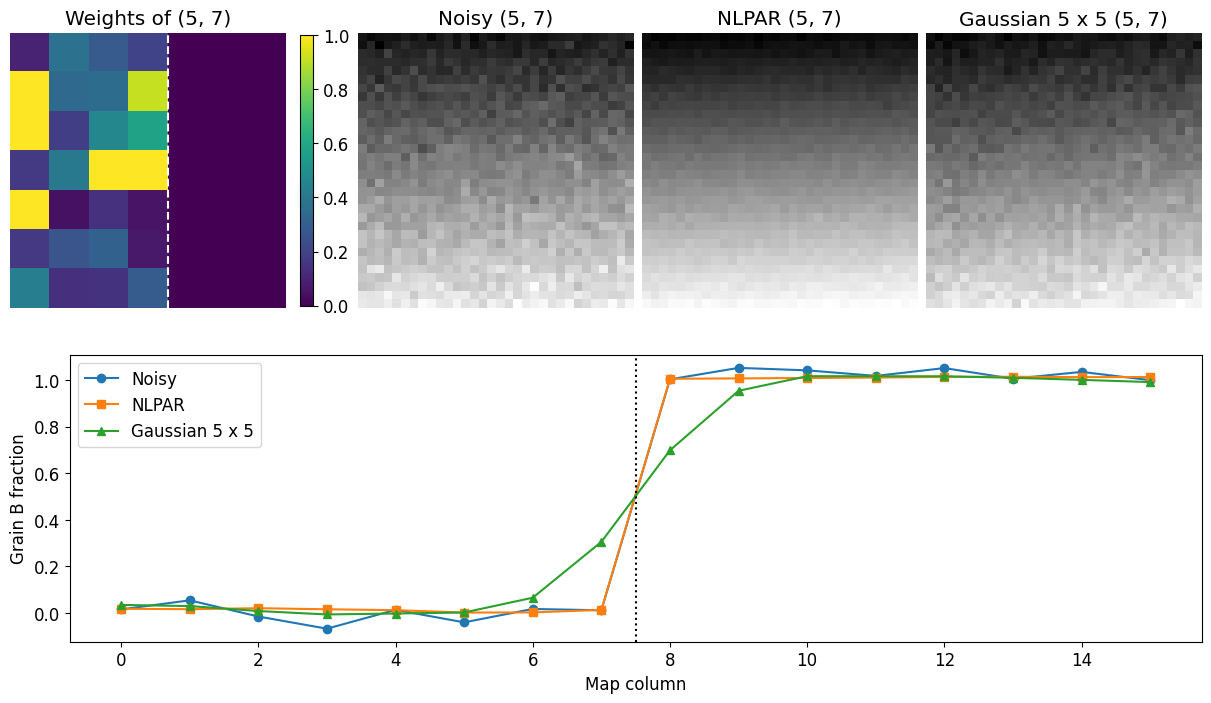

In [7]:
fig = plt.figure(figsize=(12, 7), layout="constrained")
fig_top, fig_bottom = fig.subfigures(2, 1)
axes = fig_top.subplots(1, 4)
im = axes[0].imshow(w, cmap="viridis", vmin=0, vmax=1)
axes[0].axvline(3.5, color="w", ls="--")
axes[0].set_title("Weights of (5, 7)")
fig_top.colorbar(im, ax=axes[0], shrink=0.8)
for ax, s_i, title in zip(
    axes[1:], [s2, s2_nlpar, s2_gauss], ["Noisy", "NLPAR", "Gaussian 5 x 5"]
):
    ax.imshow(s_i.inav[c0, r0].data, cmap="gray")
    ax.set_title(f"{title} (5, 7)")
for ax in axes:
    ax.axis("off")

ax = fig_bottom.subplots()
for s_i, label, marker in [
    (s2, "Noisy", "o"),
    (s2_nlpar, "NLPAR", "s"),
    (s2_gauss, "Gaussian 5 x 5", "^"),
]:
    ax.plot(grain_b_fraction(s_i), marker=marker, label=label)
ax.axvline(7.5, color="k", ls=":")
ax.set(xlabel="Map column", ylabel="Grain B fraction")
_ = ax.legend()

## Nickel: noise level, lambda and the averaged patterns

We now turn to the larger nickel dataset available with kikuchipy, $55 \times 75$ patterns of $60 \times 60$ pixels from recrystallized nickel.
The patterns are noisy, which makes it a good test case for NLPAR.

In [8]:
# Use kp.load("data.h5") to load your own data
s = kp.data.nickel_ebsd_large(allow_download=True)
s

<EBSD, title: patterns Scan 1, dimensions: (75, 55|60, 60)>

The noise level and lambda of the raw patterns:

In [9]:
sigma_raw = s.get_nlpar_sigma()
lam_raw = s.get_nlpar_lambda()
print(f"Raw: median sigma {np.median(sigma_raw):.2f}, lambda {lam_raw:.3f}")

Raw: median sigma 2.16, lambda 1.139


NLPAR is usually applied after background correction, which is what we do here.
Removing the static and dynamic background rescales every pattern to fill the 8-bit range, so the noise level in grey levels grows.

In [10]:
s.remove_static_background()
s.remove_dynamic_background()

sigma = s.get_nlpar_sigma()
print(f"Background corrected: median sigma {np.median(sigma):.2f}")

Background corrected: median sigma 17.02


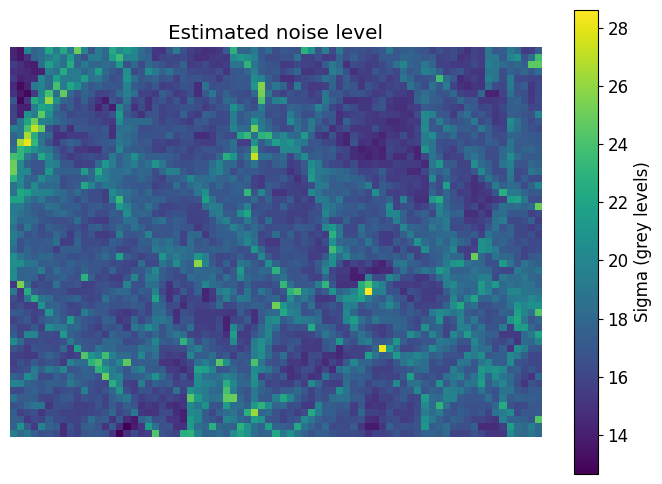

In [11]:
fig, ax = plt.subplots(figsize=(7, 5), layout="tight")
im = ax.imshow(sigma, cmap="viridis")
fig.colorbar(im, ax=ax, label="Sigma (grey levels)")
ax.set_title("Estimated noise level")
_ = ax.axis("off")

Within the grains, the noise level is between about 13 and 18 grey levels.
It is higher along the grain boundaries, where even the most similar neighbour of a pattern differs from it by more than noise.

Lambda for a few target weights follows.
A lower target leaves less weight to the pattern itself, so it gives a larger lambda and stronger averaging.
The lambda for the default target of 0.34 differs from the one of the raw patterns above, so lambda should always be optimised on the patterns that are averaged.

Target weight 0.25: lambda 3.643
Target weight 0.34: lambda 2.579
Target weight 0.50: lambda 1.667


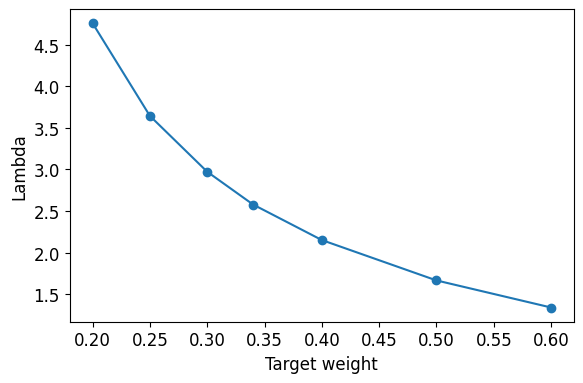

In [12]:
targets = [0.2, 0.25, 0.3, 0.34, 0.4, 0.5, 0.6]
lams = [s.get_nlpar_lambda(target_weight=tw) for tw in targets]
for tw, lam_i in zip(targets, lams):
    if tw in (0.25, 0.34, 0.5):
        print(f"Target weight {tw:.2f}: lambda {lam_i:.3f}")

fig, ax = plt.subplots(figsize=(6, 4), layout="tight")
ax.plot(targets, lams, "o-")
_ = ax.set(xlabel="Target weight", ylabel="Lambda")

We average with the default `lam=None`, which optimises lambda for the default target weight 0.34 (the value printed above), and keep the original patterns by passing `inplace=False`.
For comparison, we also average with a fixed `lam=0.7`, the default of PyEBSDIndex.

In [13]:
s_nlpar = s.average_non_local_neighbour_patterns(inplace=False)
s_nlpar07 = s.average_non_local_neighbour_patterns(lam=0.7, inplace=False)

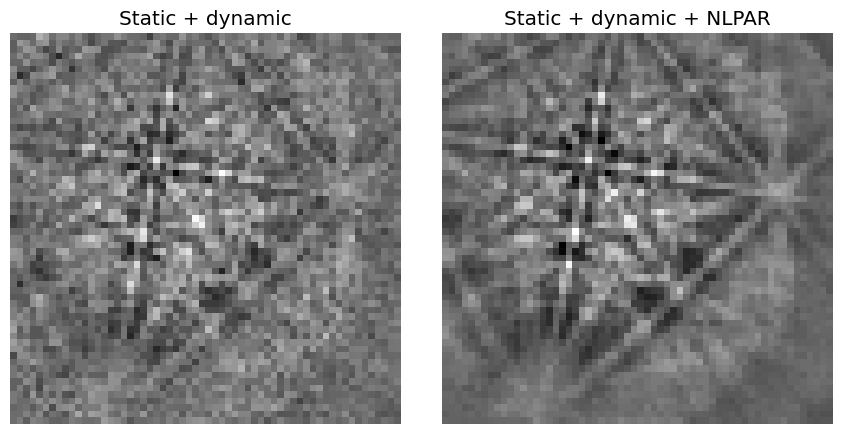

In [14]:
x, y = 50, 8
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), layout="tight")
for ax, s_i, title in zip(
    axes, [s, s_nlpar], ["Static + dynamic", "Static + dynamic + NLPAR"]
):
    ax.imshow(s_i.inav[x, y].data, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

The image quality (IQ) and average neighbour dot product (ADP) maps, both explained in the [feature maps tutorial](feature_maps.ipynb), before and after averaging:

In [15]:
iq = {}
adp = {}
for name, s_i in [("before", s), ("NLPAR", s_nlpar), ("lam 0.7", s_nlpar07)]:
    iq[name] = s_i.get_image_quality()
    adp[name] = s_i.get_average_neighbour_dot_product_map()
    print(
        f"{name:8s}: mean IQ {np.mean(iq[name]):.3f}, "
        f"mean ADP {np.mean(adp[name]):.3f}"
    )

before  : mean IQ 0.184, mean ADP 0.600


NLPAR   : mean IQ 0.323, mean ADP 0.905


lam 0.7 : mean IQ 0.253, mean ADP 0.766


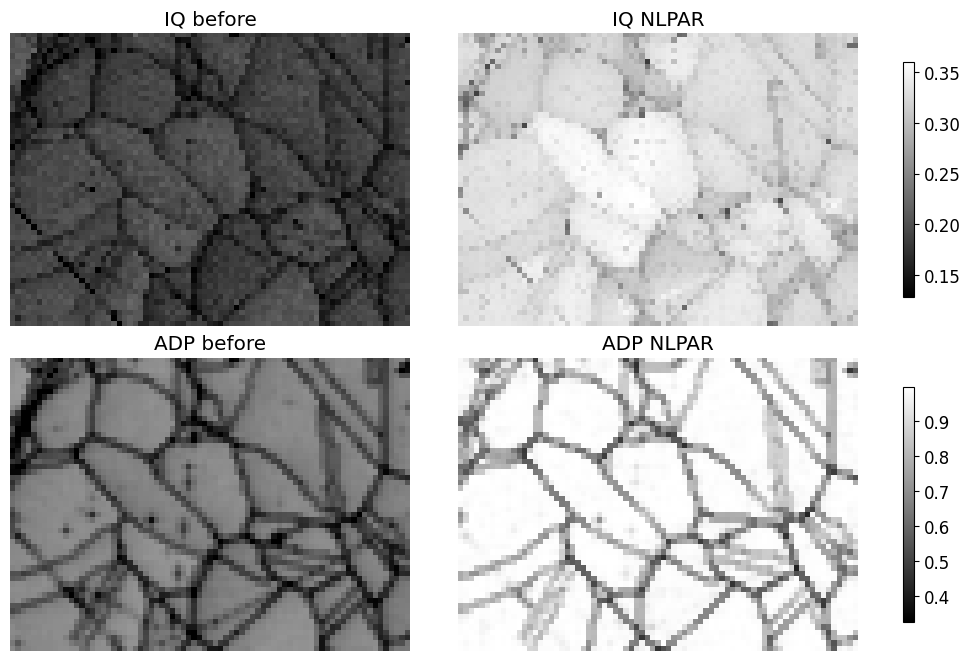

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), layout="constrained")
for j, name in enumerate(["before", "NLPAR"]):
    for i, (maps, label) in enumerate([(iq, "IQ"), (adp, "ADP")]):
        vmin, vmax = np.percentile(maps["before"], [1, 99.9])
        vmax = max(vmax, np.percentile(maps["NLPAR"], 99.9))
        im = axes[i, j].imshow(maps[name], cmap="gray", vmin=vmin, vmax=vmax)
        axes[i, j].set_title(f"{label} {name}")
        axes[i, j].axis("off")
        if j == 1:
            fig.colorbar(im, ax=axes[i, :], shrink=0.8)

The mean IQ rises from 0.184 to 0.323 and the mean ADP from 0.600 to 0.905, while the fixed `lam=0.7` averages less (IQ 0.253, ADP 0.766).
The grain interiors become more uniform, and the grain boundaries in the ADP map are as narrow after NLPAR as before it.

## Hough indexing before and after

Does the averaging help indexing?
We index every fifth pattern along both map axes (165 patterns) before and after NLPAR with Hough indexing from [PyEBSDIndex](https://pyebsdindex.readthedocs.io), as explained in the [Hough indexing tutorial](hough_indexing.ipynb).
We use the detector and the phase stored with the dataset.

In [17]:
s_sub = s.inav[::5, ::5]
s_sub_nlpar = s_nlpar.inav[::5, ::5]

xmap_ref = s_sub.xmap
phase_list = xmap_ref.phases
indexer = s_sub.detector.get_indexer(phase_list)

xmap_before = s_sub.hough_indexing(phase_list, indexer, verbose=0)
xmap_after = s_sub_nlpar.hough_indexing(phase_list, indexer, verbose=0)

Hough indexing with PyEBSDIndex information:
  PyOpenCL: False
  Projection center (Bruker, mean): (0.4231, 0.214, 0.5022)
  Indexing 165 pattern(s) in 1 chunk(s)


  Indexing speed: 274.41253 patterns/s
Hough indexing with PyEBSDIndex information:
  PyOpenCL: False
  Projection center (Bruker, mean): (0.4231, 0.214, 0.5022)
  Indexing 165 pattern(s) in 1 chunk(s)


  Indexing speed: 722.25097 patterns/s


We compare the medians of four quality metrics from PyEBSDIndex: the pattern quality `pq`, the angular fit of the detected bands `fit` (in degrees, lower is better), the number of matched bands `nmatch` and the confidence metric `cm`.
We also compute the median misorientation to the orientations stored with the dataset.

In [18]:
point_group = phase_list[phase_list.ids[0]].point_group
ori_ref = Orientation(xmap_ref.rotations, symmetry=point_group)

print(f"{'':12s} {'before':>8s} {'after':>8s}")
for key in ["pq", "fit", "nmatch", "cm"]:
    before = np.median(xmap_before.prop[key])
    after = np.median(xmap_after.prop[key])
    print(f"{key:12s} {before:8.3f} {after:8.3f}")

miso = []
for xmap_i in [xmap_before, xmap_after]:
    ori = Orientation(xmap_i.rotations, symmetry=point_group)
    miso.append(np.median(ori.angle_with(ori_ref, degrees=True)))
print(f"{'miso. (deg)':12s} {miso[0]:8.3f} {miso[1]:8.3f}")

               before    after
pq             80.564   78.926
fit             0.374    0.311
nmatch          9.000    9.000
cm              0.750    0.760
miso. (deg)     0.222    0.178


The band fit improves from 0.374 to 0.311 degrees, the confidence metric rises from 0.750 to 0.760, the number of matched bands holds at 9, and the median misorientation to the stored orientations falls from 0.222 to 0.178 degrees.
The pattern quality `pq`, however, drops by about 2 %, from 80.6 to 78.9.
This is not an effect of the subset: on all 4125 patterns of the map, the median `pq` drops from 80.6 to 79.0 as well.
On this dataset, `pq` is therefore not a measure of what the averaging gains for indexing, while the band fit and the misorientation are.

## A very noisy dataset

Raising the detector gain allows shorter exposure times, but it amplifies the noise as well as the signal.
Fast acquisitions of very noisy patterns are the case NLPAR is meant for.
The ten `ni_gain` datasets of recrystallized nickel (<cite data-cite="aanes2019electron">Aanes et al. (2019)</cite>) cover the same region of interest, $149 \times 200$ patterns of $60 \times 60$ pixels, with detector gains from 0 to 24 dB.
We take the noisiest map, number ten (24 dB), which the [hybrid indexing tutorial](hybrid_indexing.ipynb) averages with a fixed Gaussian window before indexing it.
The first map (0 dB) shows the same grains with much less noise, so its Hough indexed orientations serve as a reference to score the averaging of the 24 dB map against.

We load both maps and remove the static and dynamic background, as in the hybrid indexing tutorial.

In [19]:
s_0db = kp.data.ni_gain(1, allow_download=True)  # 0 dB, ~100 MB
s_24db = kp.data.ni_gain(10, allow_download=True)  # 24 dB, ~100 MB
for s_i in [s_0db, s_24db]:
    s_i.remove_static_background()
    s_i.remove_dynamic_background()
s_24db

<EBSD, title: Pattern, dimensions: (200, 149|60, 60)>

The pattern in row 80 and column 156, in the centre of a large grain, from both maps:

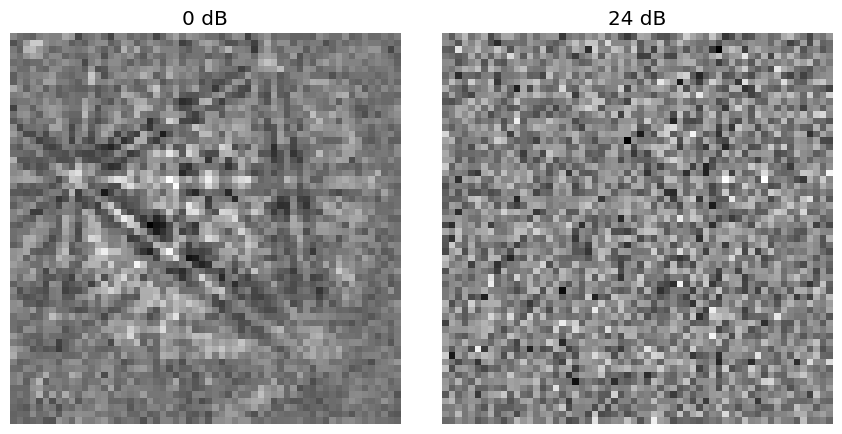

In [20]:
x24, y24 = 156, 80
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), layout="tight")
for ax, s_i, title in zip(axes, [s_0db, s_24db], ["0 dB", "24 dB"]):
    ax.imshow(s_i.inav[x24, y24].data, cmap="gray")
    ax.set_title(title)
    _ = ax.axis("off")

Hough indexing needs the sample-detector geometry.
The hybrid indexing tutorial calibrates a plane of projection centers (PCs) from separate calibration patterns.
Here, we keep it short and optimise a single PC with [hough_indexing_optimize_pc()](../reference/generated/kikuchipy.signals.EBSD.hough_indexing_optimize_pc.rst) on a grid of $5 \times 5$ patterns from the low-noise 0 dB map, starting from the initial guess used in that tutorial.
The two maps are of the same region of interest, and we assume that they share the same PC, so we use this one PC for every indexing run below.
It ignores the small variation of the PC across the map, which affects the reference and the noisy map in the same way.
The phase is taken from the nickel master pattern shipped with kikuchipy.

In [21]:
phase_list_ni = PhaseList(kp.data.nickel_ebsd_master_pattern_small().phase)

s_cal = s_0db.inav[20::40, 15::30]
indexer_cal = s_cal.detector.get_indexer(phase_list_ni)
det_cal = s_cal.hough_indexing_optimize_pc(
    pc0=[0.42, 0.22, 0.50], indexer=indexer_cal
)
pc_ni = det_cal.pc_average
print(f"PC (Bruker): ({pc_ni[0]:.4f}, {pc_ni[1]:.4f}, {pc_ni[2]:.4f})")

det_ni = s_0db.detector.deepcopy()
det_ni.pc = pc_ni
indexer_ni = det_ni.get_indexer(phase_list_ni)

PC (Bruker): (0.4193, 0.2156, 0.5025)


The reference: Hough indexing of all 29,800 patterns of the 0 dB map.

In [22]:
xmap_0db = s_0db.hough_indexing(phase_list_ni, indexer_ni, verbose=0)

point_group_ni = phase_list_ni[phase_list_ni.ids[0]].point_group
ori_0db = Orientation(xmap_0db.rotations, symmetry=point_group_ni)
print(
    f"Indexed: {xmap_0db.is_indexed.mean():.4f}, "
    f"median fit {np.median(xmap_0db.fit):.3f} deg, "
    f"median cm {np.median(xmap_0db.cm):.3f}"
)

Hough indexing with PyEBSDIndex information:
  PyOpenCL: False
  Projection center (Bruker): (0.4193, 0.2156, 0.5025)
  Indexing 29800 pattern(s) in 57 chunk(s)


  Indexing speed: 697.24831 patterns/s
Indexed: 0.9997, median fit 0.386 deg, median cm 0.740


We prepare the 24 dB map in three ways: (a) without averaging, (b) with `average_neighbour_patterns()` and a Gaussian $3 \times 3$ window (standard deviation 1), as in the hybrid indexing tutorial, and (c) with NLPAR and the default `lam=None`.
The noise level and lambda of NLPAR are estimated from the noisy patterns themselves.

In [23]:
s_24db_gauss = s_24db.average_neighbour_patterns(
    window="gaussian", window_shape=(3, 3), std=1, inplace=False
)
s_24db_nlpar = s_24db.average_non_local_neighbour_patterns(
    lam=None, inplace=False
)

sigma_0db = s_0db.get_nlpar_sigma()
sigma_24db = s_24db.get_nlpar_sigma()
lam_24db = s_24db.get_nlpar_lambda(sigma=sigma_24db)
print(
    f"Median sigma: 0 dB {np.median(sigma_0db):.2f}, "
    f"24 dB {np.median(sigma_24db):.2f}"
)
print(f"Optimised lambda of the 24 dB map: {lam_24db:.3f}")

Median sigma: 0 dB 16.84, 24 dB 34.11
Optimised lambda of the 24 dB map: 1.783


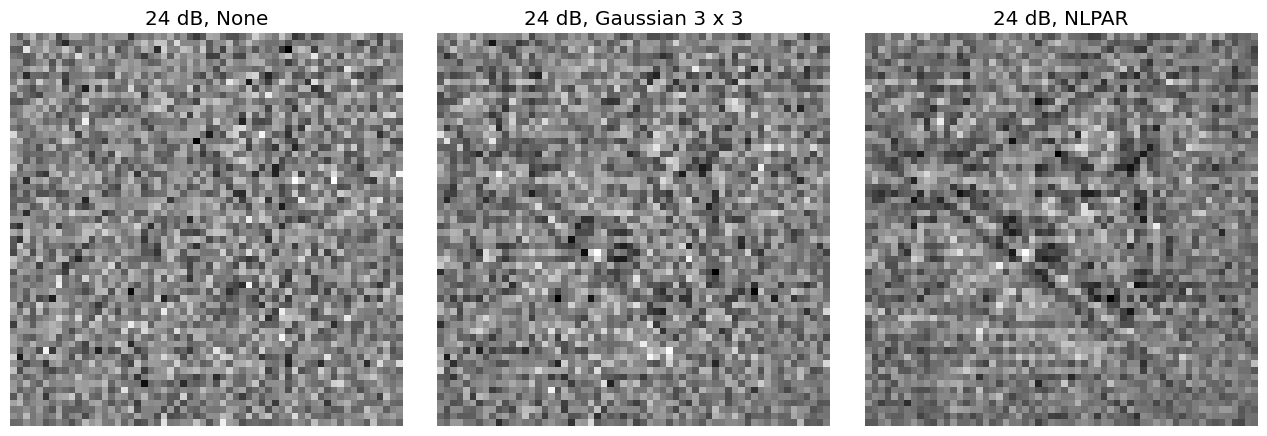

In [24]:
routes = {
    "None": s_24db,
    "Gaussian 3 x 3": s_24db_gauss,
    "NLPAR": s_24db_nlpar,
}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), layout="tight")
for ax, (name, s_i) in zip(axes, routes.items()):
    ax.imshow(s_i.inav[x24, y24].data, cmap="gray")
    ax.set_title(f"24 dB, {name}")
    _ = ax.axis("off")

We Hough index all patterns after each route, with the same PC and indexer as the reference.
Each run takes about 40 s on a 20-core workstation.

In [25]:
xmaps_24db = {}
for name, s_i in routes.items():
    xmaps_24db[name] = s_i.hough_indexing(
        phase_list_ni, indexer_ni, verbose=0
    )

Hough indexing with PyEBSDIndex information:
  PyOpenCL: False
  Projection center (Bruker): (0.4193, 0.2156, 0.5025)
  Indexing 29800 pattern(s) in 57 chunk(s)


  Indexing speed: 812.70846 patterns/s
Hough indexing with PyEBSDIndex information:
  PyOpenCL: False
  Projection center (Bruker): (0.4193, 0.2156, 0.5025)
  Indexing 29800 pattern(s) in 57 chunk(s)


  Indexing speed: 785.71940 patterns/s
Hough indexing with PyEBSDIndex information:
  PyOpenCL: False
  Projection center (Bruker): (0.4193, 0.2156, 0.5025)
  Indexing 29800 pattern(s) in 57 chunk(s)


  Indexing speed: 746.95859 patterns/s


For every map point, we compute the misorientation between the orientation found on the 24 dB map and the reference orientation of the 0 dB map.
We score each route by the fractions of points that agree within 2 and 5 degrees, and by the median misorientation.
To separate grain interiors from grain boundaries, we also count the points within 5 degrees separately for points near a boundary, those with a misorientation above 5 degrees to one of their four nearest neighbours in the reference map, and for the other (interior) points.

In [26]:
ori_grid = ori_0db.reshape(*xmap_0db.shape)
dx = ori_grid[:, 1:].angle_with(ori_grid[:, :-1], degrees=True) > 5
dy = ori_grid[1:].angle_with(ori_grid[:-1], degrees=True) > 5
near_boundary = np.zeros(xmap_0db.shape, dtype=bool)
near_boundary[:, 1:] |= dx
near_boundary[:, :-1] |= dx
near_boundary[1:] |= dy
near_boundary[:-1] |= dy
near_boundary = near_boundary.ravel()
print(f"Fraction of points near a boundary: {near_boundary.mean():.3f}")

miso_24db = {}
print(
    f"{'':16s} {'< 2 deg':>8s} {'< 5 deg':>8s} {'median':>8s} "
    f"{'interior':>9s} {'boundary':>9s}"
)
for name, xmap_i in xmaps_24db.items():
    ori = Orientation(xmap_i.rotations, symmetry=point_group_ni)
    miso_i = ori.angle_with(ori_0db, degrees=True)
    miso_24db[name] = miso_i
    within5 = miso_i < 5
    print(
        f"{name:16s} {np.mean(miso_i < 2):8.3f} {np.mean(within5):8.3f} "
        f"{np.median(miso_i):8.3f} {np.mean(within5[~near_boundary]):9.3f} "
        f"{np.mean(within5[near_boundary]):9.3f}"
    )

Fraction of points near a boundary: 0.333
                  < 2 deg  < 5 deg   median  interior  boundary
None                0.014    0.017   42.211     0.020     0.010
Gaussian 3 x 3      0.704    0.707    0.606     0.867     0.386


NLPAR               0.798    0.800    0.406     0.946     0.507


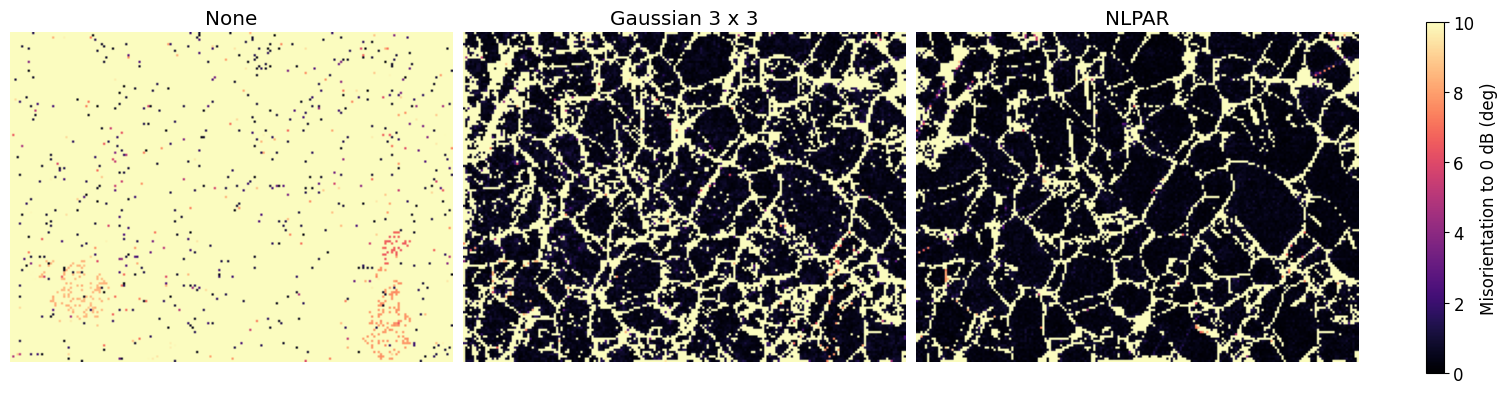

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
for ax, (name, miso_i) in zip(axes, miso_24db.items()):
    im = ax.imshow(
        miso_i.reshape(xmap_0db.shape), cmap="magma", vmin=0, vmax=10
    )
    ax.set_title(name)
    ax.axis("off")
_ = fig.colorbar(
    im, ax=axes, shrink=0.9, label="Misorientation to 0 dB (deg)"
)

Without averaging, only 0.014 of the points of the 24 dB map agree with the reference within 2 degrees.
Their median noise level is about twice that of the 0 dB map (34.11 against 16.84 grey levels), too high for the Hough transform to find the bands of most patterns, and the median misorientation of 42.211 degrees is that of essentially random orientations.
Averaging with the Gaussian $3 \times 3$ window brings 0.704 of the points within 2 degrees, and NLPAR 0.798, while the median misorientation falls from 0.606 to 0.406 degrees.
The fractions within 2 and 5 degrees hardly differ: a point either agrees closely with the reference or is indexed wrongly by a large angle.

NLPAR scores higher than the Gaussian window both in the grain interiors (0.946 against 0.867 within 5 degrees) and near the grain boundaries (0.507 against 0.386).
In the interiors, NLPAR averages over a $7 \times 7$ window with weights adapted to the patterns, so likely more patterns of the same grain contribute than in the fixed $3 \times 3$ window.
Near a boundary, the weights should keep the patterns of the other grain out of the average, which is consistent with the higher boundary score.
Still, about half of the points near a boundary disagree with the reference after NLPAR.
A likely reason is that such a pattern has fewer similar neighbours, so it is averaged less, and with the noise of this map that is often not enough for Hough indexing.
(The points counted as near a boundary, a third of the map, also include the neighbours of points that are misindexed in the reference.)

The noise level and lambda were estimated from the noisy 24 dB patterns themselves, with the default target weight, so no low-noise data or parameter tuning was needed for the averaging.
The reference is itself a Hough indexed map with a single PC and its own errors, so the scores measure agreement with it rather than accuracy.
The points that are still wrong after averaging can be re-indexed with dictionary indexing, as shown in the [hybrid indexing tutorial](hybrid_indexing.ipynb).

## Choosing the parameters

* **`lam` and `target_weight`.**
  The default `lam=None` adapts lambda to the data and is the recommended start.
  A lower `target_weight` (or a larger `lam`) averages more strongly, at the cost of mixing in more of the less similar neighbours.
  If the optimised lambda lies within 1 % of either bound of the search interval [0.001, 10], a warning is raised: the target weight is then not supported by the data.
* **`search_radius`.**
  The default radius of 3 gives a $7 \times 7$ window.
  Raise it for very noisy patterns in large grains, where more similar neighbours are available, keeping in mind that the work grows with the area of the window.
  A tuple gives one radius per navigation axis (row, column), and `search_radius=0` does nothing (with a warning).
* **`dthresh`.**
  Normalised distances below the threshold count as zero, so all neighbours closer than it get the full weight.
  A small threshold, e.g. 0.5, averages the noisy patterns of a grain more evenly; the default of 0 uses the formulas as they are.
  The same `dthresh` enters the optimisation of lambda when `lam=None`.
* **Reusing `sigma` and `lam`.**
  The noise map of `get_nlpar_sigma()` and the lambda of `get_nlpar_lambda()` can be passed back through the `sigma` and `lam` parameters.
  This is useful to inspect them first, to try several search radii on the same data, or to average several maps acquired with the same material and detector settings with the same lambda.
  With both given, the noise level is not estimated again.
* **`signal_mask`.**
  A boolean mask with `True` for pixels to exclude, e.g. outside a circular detector, removes those pixels from the distances and the noise estimate; every pixel is still averaged.
* **`dtype_out`.**
  The output keeps the data type of the input by default.
  For an integer data type, the averaged intensities are rounded to the nearest integer and clipped to its range.
  They are never rescaled per pattern, so `dtype_out="float32"` keeps the averaged values as they are, e.g. for further processing.

## Large datasets

All three methods work on lazy signals, so maps that do not fit in memory are processed chunk by chunk.
The noise level and lambda are always computed right away, while the averaging of a lazy signal stays lazy unless `lazy_output=False` is passed.
`average_non_local_neighbour_patterns()` reads a lazy signal three times (for the maximum of the map, the noise estimate and the averaging), unless both `lam` and `sigma` are given, in which case the noise estimate is skipped.
The averaged patterns are therefore best written to file instead of kept in memory.

As an example, the low-signal `si_wafer` dataset of a single crystal silicon wafer, $50 \times 50$ patterns of $480 \times 480$ pixels (576 MB), is processed like this.
It is not run here, since the dataset is a larger download:

```python
s_si = kp.data.si_wafer(allow_download=True, lazy=True)

sigma_si = s_si.get_nlpar_sigma()
lam_si = s_si.get_nlpar_lambda(sigma=sigma_si)
s_si_nlpar = s_si.average_non_local_neighbour_patterns(
    lam=lam_si, sigma=sigma_si, inplace=False
)
s_si_nlpar.save("si_wafer_nlpar.h5")
```

On a 20-core workstation, the noise estimate of this map takes about 1.6 s, and averaging from scratch into memory with `average_non_local_neighbour_patterns(lam=None, inplace=False, lazy_output=False)` takes about 8.5 s in all.
The optimised lambda is 3.42.
The noise level is flat over most of the crystal (median 1.19 grey levels), but 73 of the 2500 patterns, all of low mean intensity, have a noise level above 2 grey levels.
These give the noise map a coefficient of variation of 0.603.
For the 100 patterns at the centre of the map, the median effective number of patterns averaged (the inverse of the sum of the squared normalised weights, the pattern itself included) is 4.32 of the 49 in the window, and the mean image quality rises by a factor of 1.245, from 0.468 to 0.582.

## Differences from PyEBSDIndex and from an earlier kikuchipy proposal

The NLPAR methods follow PyEBSDIndex's NLPAR, with a number of deliberate differences.
An earlier proposal to add NLPAR to kikuchipy, [pull request #824](https://github.com/pyxem/kikuchipy/pull/824), wraps PyEBSDIndex and differs in other ways.

Here, the averaged patterns are not rescaled per pattern (as PyEBSDIndex with `rescale=False`; #824 rescales them).
Integer output is rounded to the nearest integer and clipped to the range of the data type, without depending on PyEBSDIndex's file writer.
Near a map border, the search window is shifted inward, as in PyEBSDIndex, while #824 replicates the edge patterns; map axes shorter than the window are searched in full.
The search window is the full square, and a signal mask affects the distances only while every pixel is averaged, as in PyEBSDIndex; #824 uses a boolean window, circular by default, and averages the unmasked pixels only.

The distance threshold `dthresh` enters the averaging weights and the optimisation of lambda in the same form, whereas PyEBSDIndex uses two forms and #824 uses it in the optimisation only.
The objective of the optimisation excludes neighbours outside the map, which PyEBSDIndex counts with weight 1; for the $55 \times 75$ nickel map at target weight 0.34, counting them changes lambda by about 2 %.
`lam` defaults to `None`, an optimised value, where PyEBSDIndex defaults to 0.7 and #824 to 0.9.
Lambda reaches the averaging as a 64-bit number, while PyEBSDIndex passes it on as a 32-bit number, so the two can differ by a few units in the last place of the 32-bit averages (none after rounding to integers).

Two patterns count as duplicates, which the noise estimate skips, only if their squared distance is exactly zero (PyEBSDIndex uses a threshold of 0.001).
A pair of patterns without any comparable pixel gets weight 0 (PyEBSDIndex gives weight 1).
The saturation threshold is set from the maximum of the whole map, where PyEBSDIndex uses the maximum of each processed tile, so the result does not depend on the chunking.
Finally, PyEBSDIndex is not needed at runtime, while #824 needs it for the noise estimate and lambda.